Generating walks (CPU: 1): 100%|██████████| 100/100 [00:00<00:00, 6689.27it/s]


节点 1 的 16 维向量前 5 位: 
[ 0.01360273  0.01211982  0.01521213  0.07030992 -0.06622473]


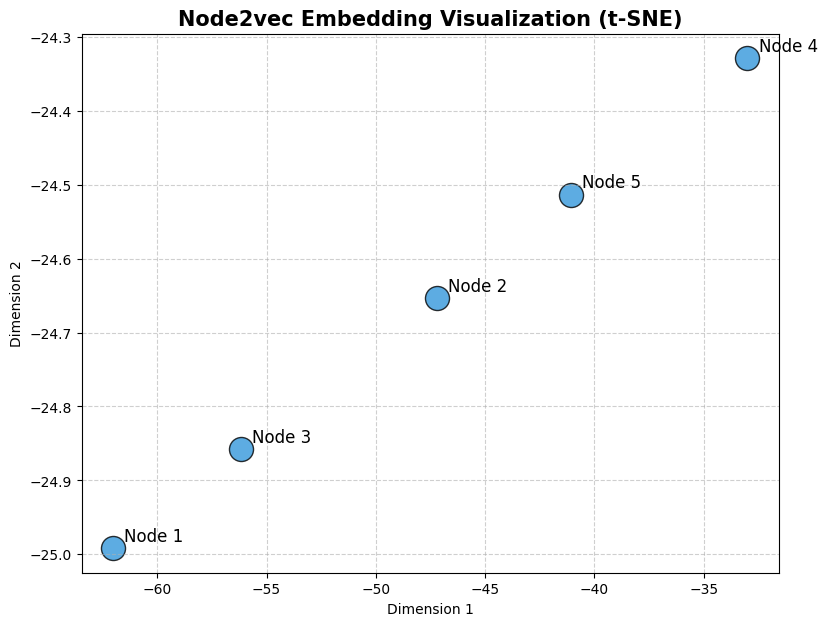

In [2]:
# 在你的 dhg 项目中，如果你能把这种“向量相似度”作为一种特征，输入到你的超图分类模型中，往往能提升模型在处理稀疏数据（Sparse Data）时的表现。 
from node2vec import Node2Vec
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
# 1. 准备数据并将节点转为字符串，避免数据类型导致的 KeyError
edges = pd.DataFrame({
    "sources": [1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 5],
    "targets": [2, 4, 5, 3, 1, 2, 5, 1, 5, 1, 3, 4]
})
edges = edges.astype(str) # 统一转成字符串

G = nx.from_pandas_edgelist(edges, source="sources", target="targets")

# 2. 训练 Node2vec
# 因为我们的图非常小，所以减少 walk_length 和 num_walks 也能跑通
node2vec = Node2Vec(G, dimensions=16, walk_length=5, num_walks=100, workers=1)
model = node2vec.fit(window=3, min_count=1)

# 3. 验证查找
target_node = '1'
print(f"节点 {target_node} 的 16 维向量前 5 位: \n{model.wv[target_node][:5]}")

# 4. 可视化：使用 t-SNE 将 16 维向量降到 2 维
# 4. 可视化准备：将列表转换为 NumPy 数组
nodes = list(G.nodes())
embeddings = np.array([model.wv[node] for node in nodes]) # 关键修正：转为 numpy 数组

# 修正 perplexity：它必须小于节点总数 (5)
# 通常建议 perplexity = 2 或 3 对于极小数据集
tsne = TSNE(n_components=2, perplexity=2, random_state=42, init='pca', learning_rate='auto')
low_dim_embs = tsne.fit_transform(embeddings)

# 5. 画图展示
plt.figure(figsize=(9, 7), dpi=100)
for i, node in enumerate(nodes):
    x, y = low_dim_embs[i, :]
    plt.scatter(x, y, s=300, color='#3498db', edgecolors='black', alpha=0.8)
    # 使用英文 Label
    plt.annotate(f"Node {node}", (x, y), xytext=(8, 5), textcoords='offset points', fontsize=12)

plt.title("Node2vec Embedding Visualization (t-SNE)", fontsize=15, fontweight='bold')
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. 提取所有节点的向量
nodes = sorted(list(G.nodes()))
embeddings = np.array([model.wv[node] for node in nodes])

# 2. 计算两两之间的余弦相似度矩阵
# 结果是一个 5x5 的矩阵，sim_matrix[i][j] 表示节点 i 和 j 的相似度
sim_matrix = cosine_similarity(embeddings)

# 3. 找出所有“未连接”但“神交已久”的节点对
print("=== 潜在关系挖掘 (Link Prediction) ===")
potential_links = []

for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        node_u = nodes[i]
        node_v = nodes[j]
        
        # 如果这两个节点在原图中没有边
        if not G.has_edge(node_u, node_v):
            score = sim_matrix[i][j]
            potential_links.append((node_u, node_v, score))

# 按照相似度从高到低排序
potential_links.sort(key=lambda x: x[2], reverse=True)

for u, v, score in potential_links:
    print(f"节点 {u} 和 节点 {v} 的相似度: {score:.4f}  <-- {'推荐关注' if score > 0.5 else '关系疏远'}")

=== 潜在关系挖掘 (Link Prediction) ===
节点 2 和 节点 5 的相似度: 0.6438  <-- 推荐关注
节点 2 和 节点 4 的相似度: 0.6060  <-- 推荐关注
节点 1 和 节点 3 的相似度: 0.0428  <-- 关系疏远
节点 3 和 节点 4 的相似度: -0.1700  <-- 关系疏远


In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1. 提取向量并计算相似度矩阵
# 确保节点顺序是固定的 (1, 2, 3, 4, 5)
sorted_nodes = sorted(list(G.nodes()))
embeddings = np.array([model.wv[node] for node in sorted_nodes])

# 计算 5x5 的余弦相似度矩阵
# sim_matrix[i][j] 的值在 [-1, 1] 之间，越接近 1 越亲密
sim_matrix = cosine_similarity(embeddings)

# 2. 遍历所有节点组合
results = []
for i in range(len(sorted_nodes)):
    for j in range(i + 1, len(sorted_nodes)):
        u, v = sorted_nodes[i], sorted_nodes[j]
        
        # 检查原图中是否有边
        has_edge = G.has_edge(u, v)
        score = sim_matrix[i][j]
        
        results.append({
            "Node A": u,
            "Node B": v,
            "Similarity": round(score, 4),
            "Existing Edge": "Yes" if has_edge else "No"
        })

# 3. 转化为 DataFrame 并分析
df_links = pd.DataFrame(results)

# 筛选出没有边但相似度最高的 Top 3（潜在推荐）
recommendations = df_links[df_links["Existing Edge"] == "No"].sort_values(by="Similarity", ascending=False)

print("=== 潜在关系推荐 (基于 Embedding 相似度) ===")
print(recommendations.head(3).to_string(index=False))

=== 潜在关系推荐 (基于 Embedding 相似度) ===
Node A Node B  Similarity Existing Edge
     2      5      0.6438            No
     2      4      0.6060            No
     1      3      0.0428            No


In [3]:
from node2vec import Node2Vec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- 实验 A：DFS 模式 (q=0.5, p=2.0) - 鼓励探索远方 ---
# 适合发现“角色相似”的节点
n2v_dfs = Node2Vec(G, dimensions=16, walk_length=10, num_walks=100, p=2.0, q=0.5, workers=1)
model_dfs = n2v_dfs.fit(window=5, min_count=1)

# --- 实验 B：BFS 模式 (p=0.5, q=2.0) - 鼓励留在原地 ---
# 适合发现“紧密的小团体”
n2v_bfs = Node2Vec(G, dimensions=16, walk_length=10, num_walks=100, p=0.5, q=2.0, workers=1)
model_bfs = n2v_bfs.fit(window=5, min_count=1)

# 计算节点 2 和 节点 4 的相似度 (它们在原图中没有连线)
v2_dfs, v4_dfs = model_dfs.wv['2'], model_dfs.wv['4']
v2_bfs, v4_bfs = model_bfs.wv['2'], model_bfs.wv['4']

sim_dfs = cosine_similarity(v2_dfs.reshape(1,-1), v4_dfs.reshape(1,-1))[0][0]
sim_bfs = cosine_similarity(v2_bfs.reshape(1,-1), v4_bfs.reshape(1,-1))[0][0]

print(f"探索模式 (DFS) 下 2 和 4 的相似度: {sim_dfs:.4f}")
print(f"聚类模式 (BFS) 下 2 和 4 的相似度: {sim_bfs:.4f}")

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:00<00:00, 2610.95it/s]

探索模式 (DFS) 下 2 和 4 的相似度: 0.9752
聚类模式 (BFS) 下 2 和 4 的相似度: 0.9592
